<a href="https://colab.research.google.com/github/KellyTBG/Ecological_delimitation_of_the_Choco_region/blob/main/02_topography.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Environmental Variable Acquisition: Topography & hidrology**

## *Developed by Kelly T. Bocanegra-González at the Bedoya Group (NYBG), May 2026.*

This notebook corresponds to the visualization and exploratory analysis stage of environmental predictors for Podostemaceae niche modelling. All large-scale topographic and hydrological processing was previously performed in a high-performance computing (HPC) environment using bash workflows and LSDTopoTools, as documented in *podostemaceae-niche-modelling.md*.

Topographic and hydrological variables were derived from the FABDEM digital elevation model (https://research-information.bris.ac.uk/en/datasets/fabdem-v1-2/), which is based on the Copernicus DEM (https://dataspace.copernicus.eu/explore-data/data-collections/copernicus-contributing-missions/collections-description/COP-DEM) and further corrected to reduce vegetation and building artifacts, improving terrain representation for geomorphological and hydrological analyses.

This notebook focuses exclusively on:

- Visualizing continental raster layers generated from LSDTopoTools outputs.
- Inspecting environmental variables for quality control.
- Preparing environmental layers for extraction at species occurrence points.
- Generating exploratory figures and summaries for downstream ecological analyses.

Subsequent notebooks will cover:

Extraction of environmental values at occurrence points.
Construction of the environmental matrix.
Soil variables from ISRIC SoilGrids.
Correlation analyses and variable selection.
PCA´s
Final predictor preparation for ecological niche modelling.

In [ ]:
# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Extract topographic and hydrological raster values
# to Podostemaceae occurrence points

!pip install rasterio geopandas -q

import os
import glob
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.sample import sample_gen
from shapely.geometry import Point

In [ ]:
# Paths

matrix_path = "/content/drive/MyDrive/Podostemaceae/Niche/04_results/Podostemaceae_environmental_matrix_bio_selected.csv"

raster_dir = "/content/drive/MyDrive/Podostemaceae/Niche/02_data_processed/fabdem"

output_path = "/content/drive/MyDrive/Podostemaceae/Niche/04_results/Podostemaceae_environmental_matrix_bio_topohydro_raw.csv"

In [ ]:
# Load occurrence/environmental matrix
df = pd.read_csv(matrix_path)

print(df.shape)
df.head()

(3500, 27)


,Species,Country,Department_Province,Locality,Latitude,Longitude,Elevation,River,Subbasin,Basin,...,SUB_AREA,UP_AREA,NEXT_DOWN,MAIN_BAS,bio_1,bio_12,bio_13,bio_14,bio_4,bio_5
0,NaN,Brazil,Pará,"Nova Mocajuba, rio Caeté, aprox. 3,1 km ao oés...",-1.288750,-46.910367,NaN,NaN,NaN,NaN,...,18906.2,18906.2,0.000000e+00,6.060008e+09,26.174999,2338.0,449.0,13.0,47.934601,32.299999
1,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,2.730772,-53.924988,NaN,NaN,NaN,NaN,...,37696.3,37696.3,6.060123e+09,6.060005e+09,25.733334,2428.0,352.0,52.0,50.915836,32.299999
2,Mourera aspera,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.928194,-51.832722,311.0,NaN,NaN,NaN,...,1046.3,15910.2,6.060769e+09,6.060017e+09,20.333334,1480.0,198.0,66.0,300.796906,29.799999
3,Apinagia richardiana,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.931139,-51.838444,310.0,NaN,NaN,NaN,...,1046.3,15910.2,6.060769e+09,6.060017e+09,20.262501,1485.0,199.0,67.0,298.733124,29.700001
4,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,3.913025,-54.261642,NaN,NaN,NaN,NaN,...,37696.3,37696.3,6.060123e+09,6.060005e+09,25.912500,2480.0,375.0,78.0,53.983353,32.299999


In [ ]:
# Check coordinate columns

print(df.columns.tolist())

['Species', 'Country', 'Department_Province', 'Locality', 'Latitude', 'Longitude', 'Elevation', 'River', 'Subbasin', 'Basin', 'Priority', 'Status', 'Date', 'Source', 'GBIF_code', 'HYBAS_ID', 'PFAF_ID', 'SUB_AREA', 'UP_AREA', 'NEXT_DOWN', 'MAIN_BAS', 'bio_1', 'bio_12', 'bio_13', 'bio_14', 'bio_4', 'bio_5']


In [ ]:
lon_col = "Longitude"
lat_col = "Latitude"

df = df.dropna(subset=[lon_col, lat_col]).copy()

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
    crs="EPSG:4326"
)

gdf.shape

(3500, 28)

In [ ]:
# Find raster files

raster_files = sorted(
    glob.glob(os.path.join(raster_dir, "**", "*.tif"), recursive=True)
)

len(raster_files), raster_files[:9]

(12,
 ['/content/drive/MyDrive/Podostemaceae/Niche/02_data_processed/fabdem/Neotropics_SLOPE_1km.tif',
  '/content/drive/MyDrive/Podostemaceae/Niche/02_data_processed/fabdem/Neotropics_hydro_FMD_area_1km.tif',
  '/content/drive/MyDrive/Podostemaceae/Niche/02_data_processed/fabdem/Neotropics_hydro_MD_area_1km.tif',
  '/content/drive/MyDrive/Podostemaceae/Niche/02_data_processed/fabdem/Neotropics_hydro_QMD_area_1km.tif',
  '/content/drive/MyDrive/Podostemaceae/Niche/02_data_processed/fabdem/Neotropics_hydro_d8_area_1km.tif',
  '/content/drive/MyDrive/Podostemaceae/Niche/02_data_processed/fabdem/Neotropics_hydro_dinf_area_1km.tif',
  '/content/drive/MyDrive/Podostemaceae/Niche/02_data_processed/fabdem/Neotropics_metrics_ASPECT_1km.tif',
  '/content/drive/MyDrive/Podostemaceae/Niche/02_data_processed/fabdem/Neotropics_metrics_CURV_1km.tif',
  '/content/drive/MyDrive/Podostemaceae/Niche/02_data_processed/fabdem/Neotropics_metrics_PLFMCURV_1km.tif'])

In [ ]:
for r in raster_files:
    print(os.path.basename(r))

# Clean raster variable names


def clean_var_name(path):

    name = os.path.basename(path)

    name = name.replace(".tif", "")
    name = name.replace("Neotropics_", "")
    name = name.replace("_1km", "")

    # clearer names
    name = name.replace("metrics_", "topo_")

    return name

new_vars = [clean_var_name(r) for r in raster_files]

new_vars

Neotropics_SLOPE_1km.tif
Neotropics_hydro_FMD_area_1km.tif
Neotropics_hydro_MD_area_1km.tif
Neotropics_hydro_QMD_area_1km.tif
Neotropics_hydro_d8_area_1km.tif
Neotropics_hydro_dinf_area_1km.tif
Neotropics_metrics_ASPECT_1km.tif
Neotropics_metrics_CURV_1km.tif
Neotropics_metrics_PLFMCURV_1km.tif
Neotropics_metrics_PROFCURV_1km.tif
Neotropics_metrics_hs_1km (1).tif
Neotropics_metrics_hs_1km.tif


['SLOPE',
 'hydro_FMD_area',
 'hydro_MD_area',
 'hydro_QMD_area',
 'hydro_d8_area',
 'hydro_dinf_area',
 'topo_ASPECT',
 'topo_CURV',
 'topo_PLFMCURV',
 'topo_PROFCURV',
 'topo_hs (1)',
 'topo_hs']

In [ ]:
# Create GeoDataFrame

lon_col = "Longitude"
lat_col = "Latitude"

df = df.dropna(subset=[lon_col, lat_col]).copy()

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
    crs="EPSG:4326"
)

print(gdf.shape)

gdf.head()

(3500, 28)


,Species,Country,Department_Province,Locality,Latitude,Longitude,Elevation,River,Subbasin,Basin,...,UP_AREA,NEXT_DOWN,MAIN_BAS,bio_1,bio_12,bio_13,bio_14,bio_4,bio_5,geometry
0,NaN,Brazil,Pará,"Nova Mocajuba, rio Caeté, aprox. 3,1 km ao oés...",-1.288750,-46.910367,NaN,NaN,NaN,NaN,...,18906.2,0.000000e+00,6.060008e+09,26.174999,2338.0,449.0,13.0,47.934601,32.299999,POINT (-46.91037 -1.28875)
1,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,2.730772,-53.924988,NaN,NaN,NaN,NaN,...,37696.3,6.060123e+09,6.060005e+09,25.733334,2428.0,352.0,52.0,50.915836,32.299999,POINT (-53.92499 2.73077)
2,Mourera aspera,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.928194,-51.832722,311.0,NaN,NaN,NaN,...,15910.2,6.060769e+09,6.060017e+09,20.333334,1480.0,198.0,66.0,300.796906,29.799999,POINT (-51.83272 -23.92819)
3,Apinagia richardiana,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.931139,-51.838444,310.0,NaN,NaN,NaN,...,15910.2,6.060769e+09,6.060017e+09,20.262501,1485.0,199.0,67.0,298.733124,29.700001,POINT (-51.83844 -23.93114)
4,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,3.913025,-54.261642,NaN,NaN,NaN,NaN,...,37696.3,6.060123e+09,6.060005e+09,25.912500,2480.0,375.0,78.0,53.983353,32.299999,POINT (-54.26164 3.91302)


In [ ]:
# Extract raster values to occurrence points

coords = [(geom.x, geom.y) for geom in gdf.geometry]

for raster_path in raster_files:

    var_name = clean_var_name(raster_path)

    print(f"Extracting: {var_name}")

    with rasterio.open(raster_path) as src:

        # Reproject points if needed
        if src.crs != gdf.crs:

            gdf_proj = gdf.to_crs(src.crs)
            coords_proj = [(geom.x, geom.y) for geom in gdf_proj.geometry]

        else:
            coords_proj = coords

        values = []

        for val in src.sample(coords_proj):

            v = val[0]

            if src.nodata is not None and v == src.nodata:
                values.append(None)
            else:
                values.append(v)

        gdf[var_name] = values

print("Extraction completed.")

Extracting: SLOPE
Extracting: hydro_FMD_area
Extracting: hydro_MD_area
Extracting: hydro_QMD_area
Extracting: hydro_d8_area
Extracting: hydro_dinf_area
Extracting: topo_ASPECT
Extracting: topo_CURV
Extracting: topo_PLFMCURV
Extracting: topo_PROFCURV
Extracting: topo_hs (1)
Extracting: topo_hs
Extraction completed.


In [ ]:
# Check extracted variables

new_vars = [clean_var_name(r) for r in raster_files]

df_check = gdf.drop(columns="geometry").copy()

print(df_check.shape)
df_check[new_vars].head()

(3500, 39)


,SLOPE,hydro_FMD_area,hydro_MD_area,hydro_QMD_area,hydro_d8_area,hydro_dinf_area,topo_ASPECT,topo_CURV,topo_PLFMCURV,topo_PROFCURV,topo_hs (1),topo_hs
0,0.029648,3.513653e+06,253429.515625,3522940.5,9.995076e+05,3.350890e+06,209.594894,0.000004,-2.290816e-07,-0.000010,180.661530,180.661530
1,0.042573,3.795543e+06,66717.859375,3776335.0,4.219286e+06,3.323109e+06,200.367462,-0.000173,1.972856e-07,-0.000082,182.025757,182.025757
2,0.028862,4.148891e+08,112747.320312,420951072.0,3.896092e+08,3.895505e+08,224.208862,0.000116,-5.076539e-07,0.000220,180.251007,180.251007
3,0.083837,2.933640e+08,126637.726562,295876384.0,2.431544e+08,2.455934e+08,183.625458,-0.000026,-5.662302e-06,0.000157,170.399124,170.399124
4,0.031316,5.433663e+08,28359.277344,552428224.0,4.342015e+08,3.752185e+08,252.934631,0.000021,-2.926894e-06,0.000211,180.053406,180.053406


In [ ]:
# Missing values in extracted variables

missing_summary = (
    df_check[new_vars]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary

,0
hydro_FMD_area,42
hydro_QMD_area,42
topo_PROFCURV,18
topo_ASPECT,18
hydro_MD_area,4
SLOPE,4
hydro_dinf_area,4
hydro_d8_area,4
topo_CURV,4
topo_PLFMCURV,4


In [ ]:
# Basic descriptive statistics

df_check[new_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
SLOPE,3496.0,1.429544e-01,1.277685e-01,0.000000,0.046834,1.004354e-01,2.148111e-01,8.672180e-01
hydro_FMD_area,3458.0,8.398847e+07,3.116497e+08,2628.894287,131496.433594,1.788681e+06,2.210664e+07,5.223603e+09
hydro_MD_area,3496.0,2.491642e+06,1.017392e+07,2317.174316,58460.840820,3.143843e+05,1.265269e+06,1.854032e+08
hydro_QMD_area,3458.0,8.551304e+07,3.178889e+08,2695.797363,132915.605469,1.825760e+06,2.259068e+07,5.368515e+09
hydro_d8_area,3496.0,7.505012e+07,2.972838e+08,3311.762939,106253.421875,1.437323e+06,1.866305e+07,5.323081e+09
hydro_dinf_area,3496.0,8.135641e+07,3.268960e+08,4460.572754,112795.281250,1.577120e+06,1.998768e+07,4.953644e+09
topo_ASPECT,3482.0,1.788826e+02,3.709086e+01,53.802612,155.760361,1.795194e+02,2.017991e+02,3.084644e+02
topo_CURV,3496.0,7.284283e-05,2.692373e-04,-0.001787,-0.000027,3.904484e-05,1.670465e-04,1.700958e-03
topo_PLFMCURV,3496.0,-1.491206e-05,3.642546e-05,-0.000364,-0.000019,-3.233370e-06,-1.831130e-07,2.554334e-04
topo_PROFCURV,3482.0,2.505558e-04,3.192051e-04,-0.000920,0.000057,1.888517e-04,3.908206e-04,4.361338e-03


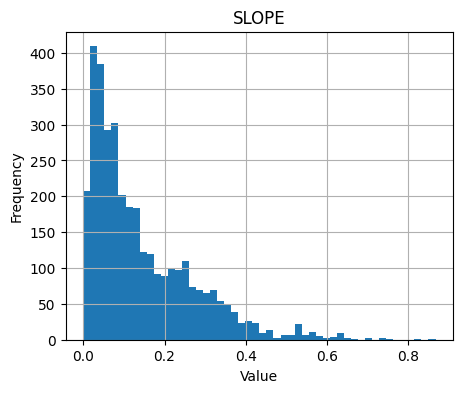

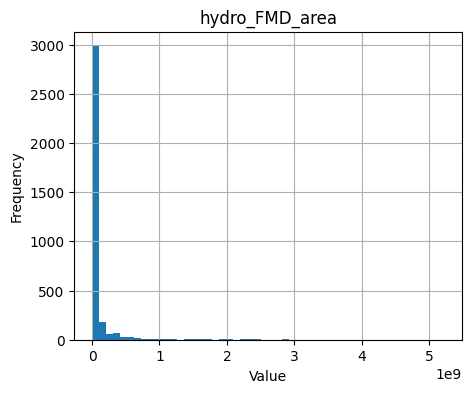

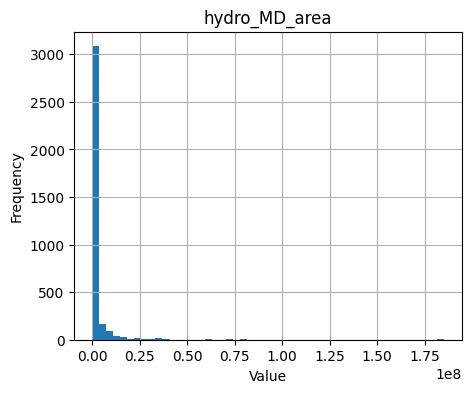

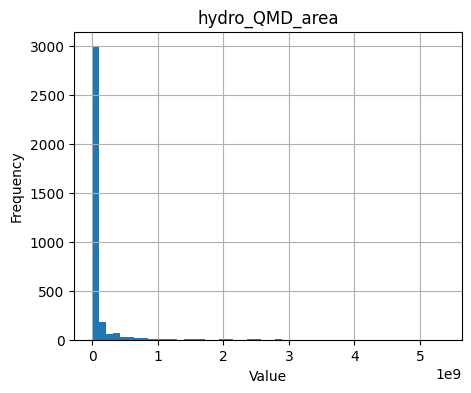

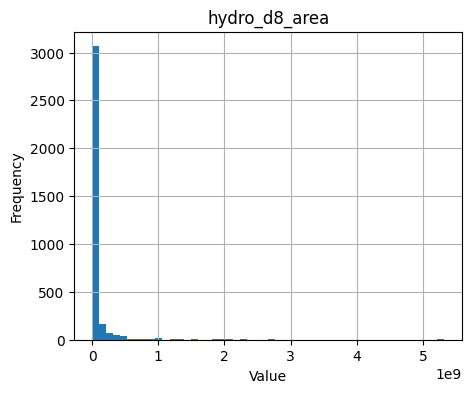

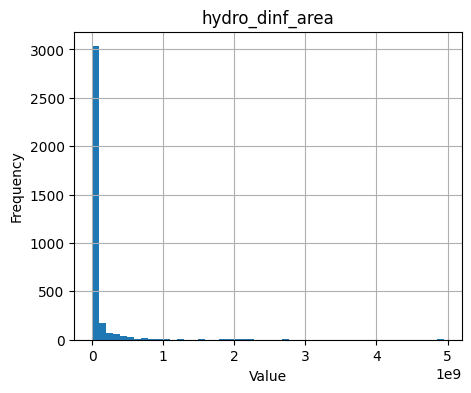

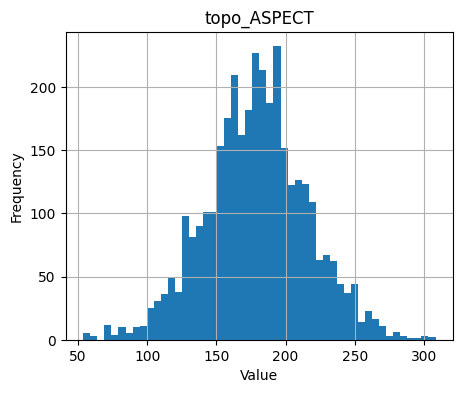

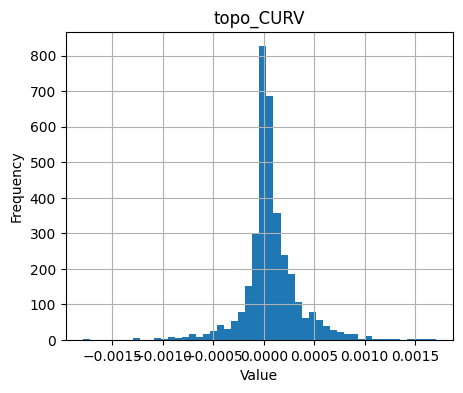

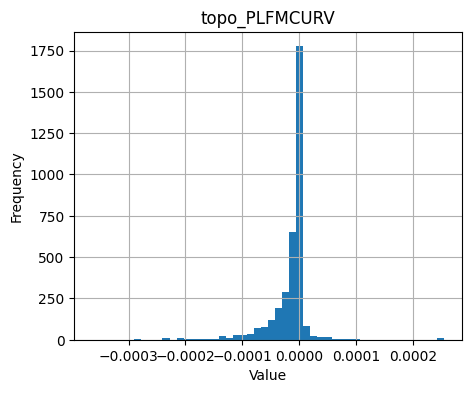

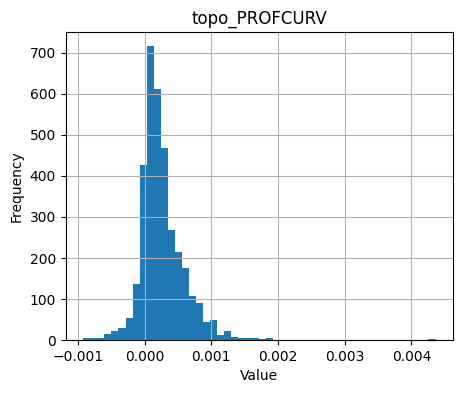

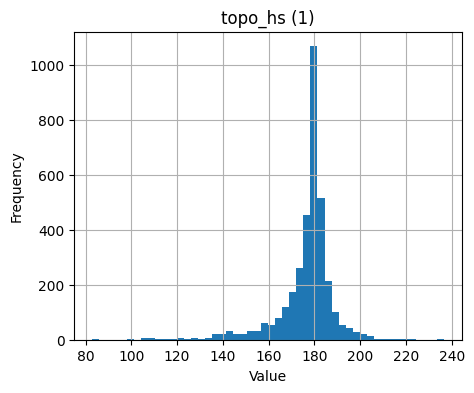

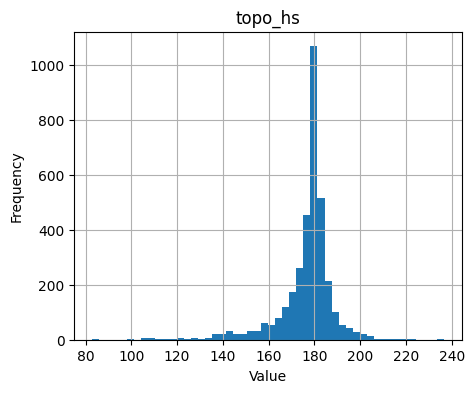

In [ ]:
# Histograms of topographic/hydrological variables

import matplotlib.pyplot as plt

for var in new_vars:

    plt.figure(figsize=(5,4))

    df_check[var].hist(bins=50)

    plt.title(var)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

    plt.show()

In [ ]:
# Log10 transform hydrological variables

import numpy as np

hydro_vars = [
    col for col in df_check.columns
    if "hydro" in col
]

print(hydro_vars)

['hydro_FMD_area', 'hydro_MD_area', 'hydro_QMD_area', 'hydro_d8_area', 'hydro_dinf_area']


In [ ]:
# Create transformed hydro variables

for var in hydro_vars:

    new_name = f"{var}_log10"

    df_check[new_name] = np.log10(df_check[var] + 1)

print("Hydrological variables transformed.")

Hydrological variables transformed.


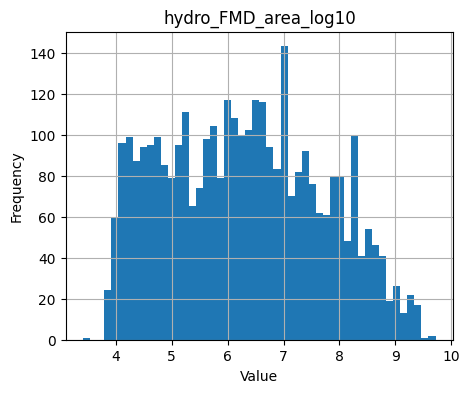

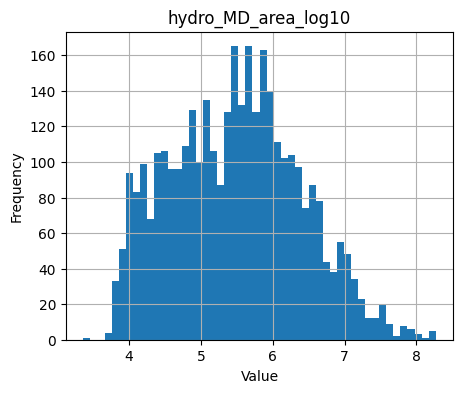

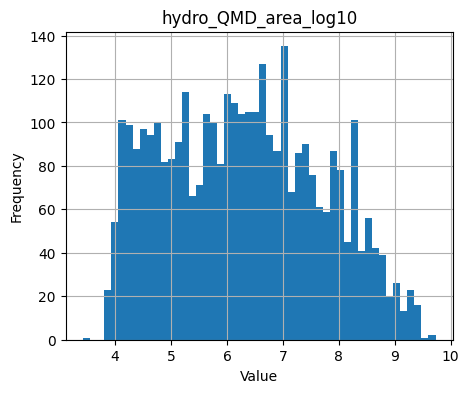

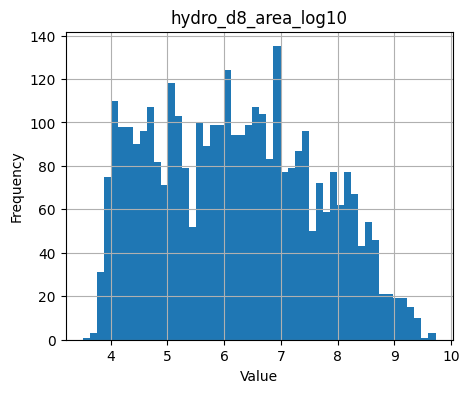

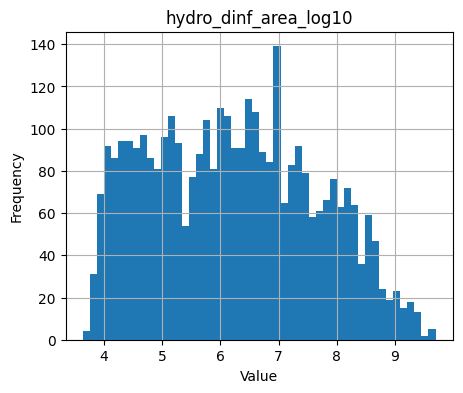

In [ ]:
# Histograms of transformed hydrological variables

hydro_log_vars = [
    col for col in df_check.columns
    if "_log10" in col
]

for var in hydro_log_vars:

    plt.figure(figsize=(5,4))

    df_check[var].hist(bins=50)

    plt.title(var)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

    plt.show()

In [ ]:
# Topographic and hydrological variables only

corr_vars = [

    "SLOPE",

    "topo_CURV",
    "topo_PLFMCURV",
    "topo_PROFCURV",

    "hydro_FMD_area_log10",
    "hydro_d8_area_log10",
    "hydro_dinf_area_log10",
    "hydro_MD_area_log10",
    "hydro_QMD_area_log10",
]

corr_df = df_check[corr_vars].copy()

corr_df.head()

,SLOPE,topo_CURV,topo_PLFMCURV,topo_PROFCURV,hydro_FMD_area_log10,hydro_d8_area_log10,hydro_dinf_area_log10,hydro_MD_area_log10,hydro_QMD_area_log10
0,0.029648,0.000004,-2.290816e-07,-0.000010,6.545759,5.999787,6.525160,5.403859,6.546905
1,0.042573,-0.000173,1.972856e-07,-0.000082,6.579274,6.625239,6.521545,4.824249,6.577071
2,0.028862,0.000116,-5.076539e-07,0.000220,8.617932,8.590629,8.590564,5.052110,8.624232
3,0.083837,-0.000026,-5.662302e-06,0.000157,8.467407,8.385882,8.390217,5.102567,8.471110
4,0.031316,0.000021,-2.926894e-06,0.000211,8.735093,8.637691,8.574284,4.452710,8.742276


In [ ]:
# Pearson correlation matrix

corr_matrix = corr_df.corr(method="pearson")

corr_matrix.round(2)

,SLOPE,topo_CURV,topo_PLFMCURV,topo_PROFCURV,hydro_FMD_area_log10,hydro_d8_area_log10,hydro_dinf_area_log10,hydro_MD_area_log10,hydro_QMD_area_log10
SLOPE,1.00,0.15,-0.47,0.29,-0.21,-0.19,-0.20,-0.08,-0.21
topo_CURV,0.15,1.00,-0.17,0.72,0.25,0.27,0.26,0.33,0.25
topo_PLFMCURV,-0.47,-0.17,1.00,-0.56,0.04,0.02,0.03,-0.07,0.04
topo_PROFCURV,0.29,0.72,-0.56,1.00,0.26,0.28,0.26,0.33,0.26
hydro_FMD_area_log10,-0.21,0.25,0.04,0.26,1.00,0.94,0.97,0.77,1.00
hydro_d8_area_log10,-0.19,0.27,0.02,0.28,0.94,1.00,0.93,0.77,0.94
hydro_dinf_area_log10,-0.20,0.26,0.03,0.26,0.97,0.93,1.00,0.78,0.97
hydro_MD_area_log10,-0.08,0.33,-0.07,0.33,0.77,0.77,0.78,1.00,0.77
hydro_QMD_area_log10,-0.21,0.25,0.04,0.26,1.00,0.94,0.97,0.77,1.00


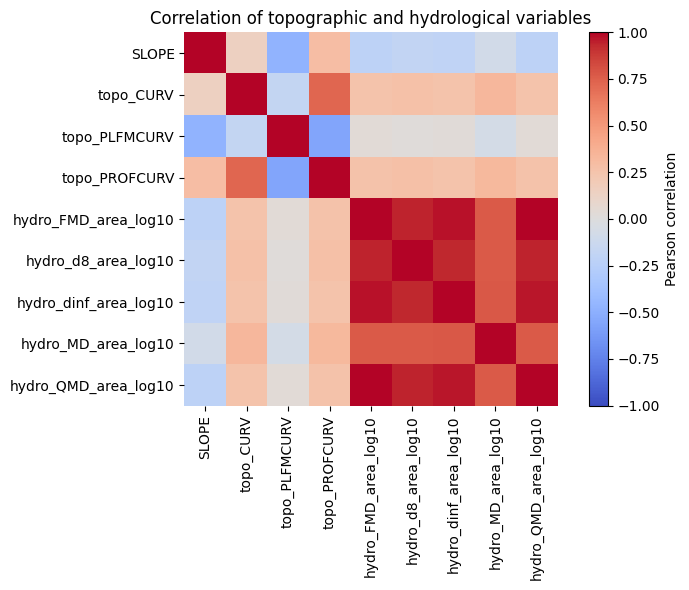

Figure saved:
/content/drive/MyDrive/Podostemaceae/Niche/05_figures/topohydro_correlation_heatmap.png


In [ ]:
# Correlation heatmap

import matplotlib.pyplot as plt
import numpy as np

# output path
fig_path = "/content/drive/MyDrive/Podostemaceae/Niche/05_figures/topohydro_correlation_heatmap.png"

# correlation matrix
corr_matrix = corr_df.corr(method="pearson")

# plot
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    interpolation="none"
)

# Remove external black border
for spine in ax.spines.values():
    spine.set_visible(False)

# ticks
ax.set_xticks(np.arange(len(corr_vars)))
ax.set_yticks(np.arange(len(corr_vars)))

ax.set_xticklabels(corr_vars, rotation=90)
ax.set_yticklabels(corr_vars)

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson correlation")

# title
plt.title("Correlation of topographic and hydrological variables")

# layout
plt.tight_layout()

# save
plt.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(fig_path)

In [ ]:
# Extract and save highly correlated variable pairs

import pandas as pd
import numpy as np

# correlation threshold
threshold = 0.80

# correlation matrix
corr_matrix = corr_df.corr(method="pearson")

# extract highly correlated pairs
pairs = []

for i in range(len(corr_matrix.columns)):

    for j in range(i + 1, len(corr_matrix.columns)):

        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) >= threshold:

            pairs.append({
                "Variable_1": var1,
                "Variable_2": var2,
                "Pearson_r": corr_value
            })

# create dataframe
high_corr_df = pd.DataFrame(pairs)

# sort by absolute correlation
high_corr_df = high_corr_df.sort_values(
    by="Pearson_r",
    key=lambda x: abs(x),
    ascending=False
)

# display
display(high_corr_df)

# save table
output_corr = "/content/drive/MyDrive/Podostemaceae/Niche/04_results/highly_correlated_TOPO_pairs.csv"

high_corr_df.to_csv(output_corr, index=False)

print("Saved:")
print(output_corr)

,Variable_1,Variable_2,Pearson_r
2,hydro_FMD_area_log10,hydro_QMD_area_log10,0.999971
1,hydro_FMD_area_log10,hydro_dinf_area_log10,0.968983
5,hydro_dinf_area_log10,hydro_QMD_area_log10,0.968679
4,hydro_d8_area_log10,hydro_QMD_area_log10,0.944743
0,hydro_FMD_area_log10,hydro_d8_area_log10,0.944559
3,hydro_d8_area_log10,hydro_dinf_area_log10,0.930039


Saved:
/content/drive/MyDrive/Podostemaceae/Niche/04_results/highly_correlated_TOPO_pairs.csv


## Interpretation of topographic and hydrological variables

### Topographic variables

#### `SLOPE`
Represents terrain steepness or inclination. High values are associated with mountainous regions, rapids, waterfalls, and deeply incised river valleys, whereas low values correspond to floodplains and flat landscapes. This variable is expected to be highly relevant for Podostemaceae because many species are associated with steep, high-energy river systems.

#### `topo_CURV`
General surface curvature. Describes whether the terrain is locally convex, concave, or planar. Positive values indicate convex surfaces, negative values indicate concave surfaces, and values near zero represent flat terrain. Curvature may influence local water accumulation and erosion processes.

#### `topo_PLFMCURV`
Planform curvature (horizontal curvature). Describes lateral flow convergence or divergence across the terrain surface. Negative values indicate convergent flow, while positive values indicate divergent flow. This variable may reflect local hydrological confinement and lateral concentration of water flow.

#### `topo_PROFCURV`
Profile curvature (longitudinal curvature). Describes how slope changes along the downslope flow direction. Positive values indicate accelerating flow, whereas negative values indicate decelerating flow. This variable may be associated with hydraulic energy, rapids, and turbulent flow conditions relevant to Podostemaceae habitats.


### Hydrological variables

#### `hydro_d8_area`
Upslope contributing area calculated using the D8 flow-routing algorithm, where each raster cell drains toward a single downslope direction. Represents drainage accumulation and river network connectivity but may oversimplify hydrological flow patterns.

#### `hydro_dinf_area`
Upslope contributing area calculated using the D∞ (D-infinity) flow-routing algorithm, which allows flow partitioning across multiple downslope directions. This approach provides a more realistic representation of distributed hydrological flow and river connectivity.

#### `hydro_FMD_area`
Flow metric distance area. Represents a hydrological metric combining drainage accumulation and effective flow distance within the river network. This variable may capture the functional position of sites within hydrological systems.

#### `hydro_MD_area`
Metric distance area. Represents a hydrological metric related to flow distance and upstream contributing area within the drainage network. This variable may capture the relative position of sites along the river system and potential hydrological connectivity. At this stage, it was still being processed and will be evaluated once available.

#### `hydro_QMD_area`
Quantile/weighted metric distance area. Represents a related hydrological metric derived from flow distance and contributing area, potentially emphasizing differences in hydrological position or flow accumulation across the drainage network. At this stage, it was still being processed and will be evaluated once available.

### Excluded variables

#### `topo_hs`
Hillshade layer used exclusively for terrain visualization and illumination effects. It does not represent an ecological or geomorphological predictor and was excluded from downstream analyses.

#### `topo_ASPECT`
Terrain aspect (slope orientation). Although aspect may influence local microclimatic conditions, it is a circular variable (0° = 360°), which complicates interpretation in standard linear statistical analyses such as Pearson correlation and PCA. Additionally, its ecological relevance at continental scale is likely limited for river-associated Podostemaceae species.


In [ ]:
# Create final selected topo-hydro dataset

selected_topo_vars = [

    "SLOPE",
    "topo_CURV",
    "topo_PLFMCURV",
    "topo_PROFCURV",
    "hydro_dinf_area_log10",
    "hydro_MD_area_log10"
]

# keep all original columns + selected topo variables
final_df = df_check.copy()

# remove redundant hydro variables and excluded variables
drop_vars = [

    "hydro_FMD_area",
    "hydro_d8_area",
    "hydro_dinf_area",

    "hydro_FMD_area_log10",
    "hydro_d8_area_log10",

     "hydro_MD_area",
     "hydro_QMD_area",
     "hydro_QMD_area_log10",

     "topo_hs",
     "topo_ASPECT"
]

final_df = final_df.drop(
    columns=[c for c in drop_vars if c in final_df.columns]
)

# save final table
output_final = "/content/drive/MyDrive/Podostemaceae/Niche/04_results/Podostemaceae_environmental_matrix_bio_topo_selected.csv"

final_df.to_csv(output_final, index=False)

print("Saved:")
print(output_final)

print(final_df.shape)

final_df.head()

Saved:
/content/drive/MyDrive/Podostemaceae/Niche/04_results/Podostemaceae_environmental_matrix_bio_topo_selected.csv
(3500, 34)


,Species,Country,Department_Province,Locality,Latitude,Longitude,Elevation,River,Subbasin,Basin,...,bio_14,bio_4,bio_5,SLOPE,topo_CURV,topo_PLFMCURV,topo_PROFCURV,topo_hs (1),hydro_MD_area_log10,hydro_dinf_area_log10
0,NaN,Brazil,Pará,"Nova Mocajuba, rio Caeté, aprox. 3,1 km ao oés...",-1.288750,-46.910367,NaN,NaN,NaN,NaN,...,13.0,47.934601,32.299999,0.029648,0.000004,-2.290816e-07,-0.000010,180.661530,5.403859,6.525160
1,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,2.730772,-53.924988,NaN,NaN,NaN,NaN,...,52.0,50.915836,32.299999,0.042573,-0.000173,1.972856e-07,-0.000082,182.025757,4.824249,6.521545
2,Mourera aspera,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.928194,-51.832722,311.0,NaN,NaN,NaN,...,66.0,300.796906,29.799999,0.028862,0.000116,-5.076539e-07,0.000220,180.251007,5.052110,8.590564
3,Apinagia richardiana,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.931139,-51.838444,310.0,NaN,NaN,NaN,...,67.0,298.733124,29.700001,0.083837,-0.000026,-5.662302e-06,0.000157,170.399124,5.102567,8.390217
4,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,3.913025,-54.261642,NaN,NaN,NaN,NaN,...,78.0,53.983353,32.299999,0.031316,0.000021,-2.926894e-06,0.000211,180.053406,4.452710,8.574284


In [ ]:
final_df.columns.tolist()

['Species',
 'Country',
 'Department_Province',
 'Locality',
 'Latitude',
 'Longitude',
 'Elevation',
 'River',
 'Subbasin',
 'Basin',
 'Priority',
 'Status',
 'Date',
 'Source',
 'GBIF_code',
 'HYBAS_ID',
 'PFAF_ID',
 'SUB_AREA',
 'UP_AREA',
 'NEXT_DOWN',
 'MAIN_BAS',
 'bio_1',
 'bio_12',
 'bio_13',
 'bio_14',
 'bio_4',
 'bio_5',
 'SLOPE (1)',
 'SLOPE',
 'hydro_d8_area (1)',
 'topo_ASPECT (1)',
 'topo_CURV (1)',
 'topo_CURV',
 'topo_PLFMCURV (1)',
 'topo_PLFMCURV',
 'topo_PROFCURV (1)',
 'topo_PROFCURV',
 'topo_hs (1)',
 'hydro_MD_area_log10',
 'hydro_d8_area (1)_log10',
 'hydro_dinf_area_log10']

**Here starts PCA and charts**